명사 추출 시작 (문장별 개별 분석으로 속도를 높였습니다)...


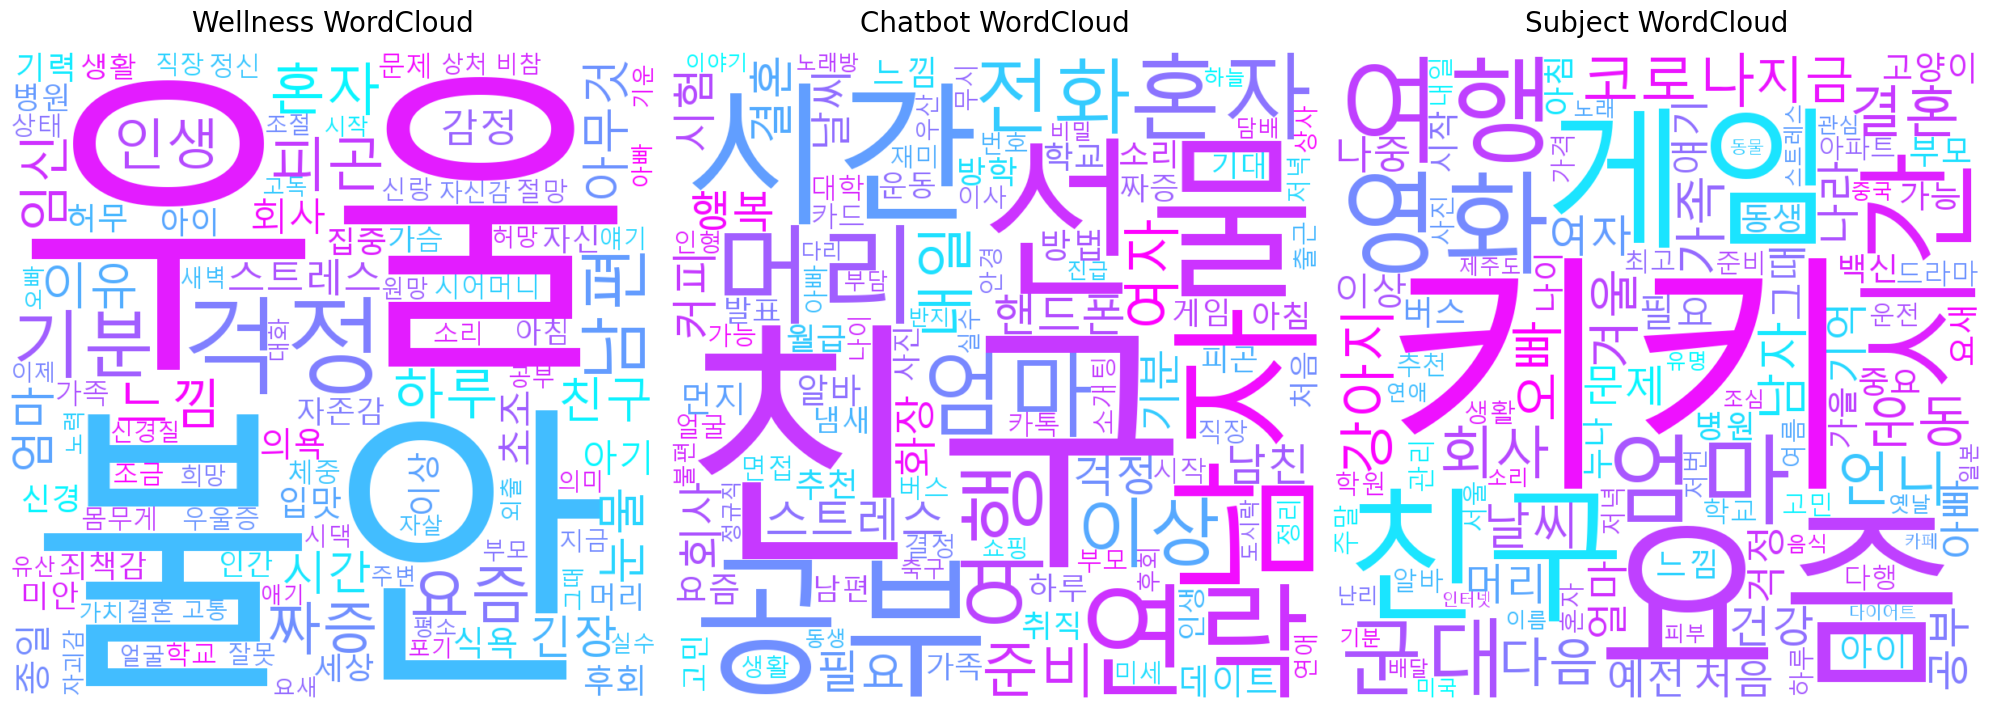

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from kiwipiepy import Kiwi
from collections import Counter

# 1. Kiwi 초기화 및 데이터 로드
kiwi = Kiwi()
df_wellness = pd.read_csv('cleaned_wellness.csv')
df_subject = pd.read_csv('cleaned_subject.csv')
df_chatbot = pd.read_csv('cleaned_chatbot.csv')

def get_pure_nouns_fixed(df, column_name='utterance'):
    # 데이터를 리스트로 변환
    sentences = df[column_name].astype(str).tolist()
    
    nouns = []
    
    # [수정 핵심] 거대한 문자열로 합치지 않고, 문장을 하나씩 루프로 처리합니다.
    # 이렇게 하면 메모리 부하가 없어 15분 걸리던 작업이 1분 내외로 끝납니다.
    for sent in sentences:
        if not sent.strip(): continue # 빈 줄 건너뛰기
        
        # 형태소 분석 (가장 높은 확률의 결과 1개만 가져옴)
        analysis = kiwi.analyze(sent)
        
        # analysis[0][0]은 분석된 토큰들의 리스트입니다.
        for token in analysis[0][0]:
            # 일반 명사(NNG), 고유 명사(NNP)만 추출 + 2글자 이상
            if token.tag in ['NNG', 'NNP'] and len(token.form) > 1:
                nouns.append(token.form)
    
    # 불용어 설정 (명사 중에서 제외할 단어)
    stopwords = ['생각', '오늘', '하나', '무엇', '때문', '정도', '그거', '이번', '사람', '마음']
    filtered_nouns = [n for n in nouns if n not in stopwords]
    
    return Counter(filtered_nouns)

# 3. 시각화 설정
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
datasets = [df_wellness, df_chatbot, df_subject]
titles = ['Wellness WordCloud', 'Chatbot WordCloud', 'Subject WordCloud']

print("명사 추출 시작 (문장별 개별 분석으로 속도를 높였습니다)...")

for i, df in enumerate(datasets):
    counts = get_pure_nouns_fixed(df)
    
    if not counts:
        print(f"{titles[i]} 데이터에 명사가 없습니다.")
        continue

    # 워드클라우드 생성
    wc = WordCloud(
        font_path="malgun.ttf", 
        background_color="white",
        width=800, height=800,
        max_words=100,
        colormap='cool'
    ).generate_from_frequencies(counts)
    
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(titles[i], fontsize=20, pad=15)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

세련된 색조합으로 워드클라우드 생성 중...


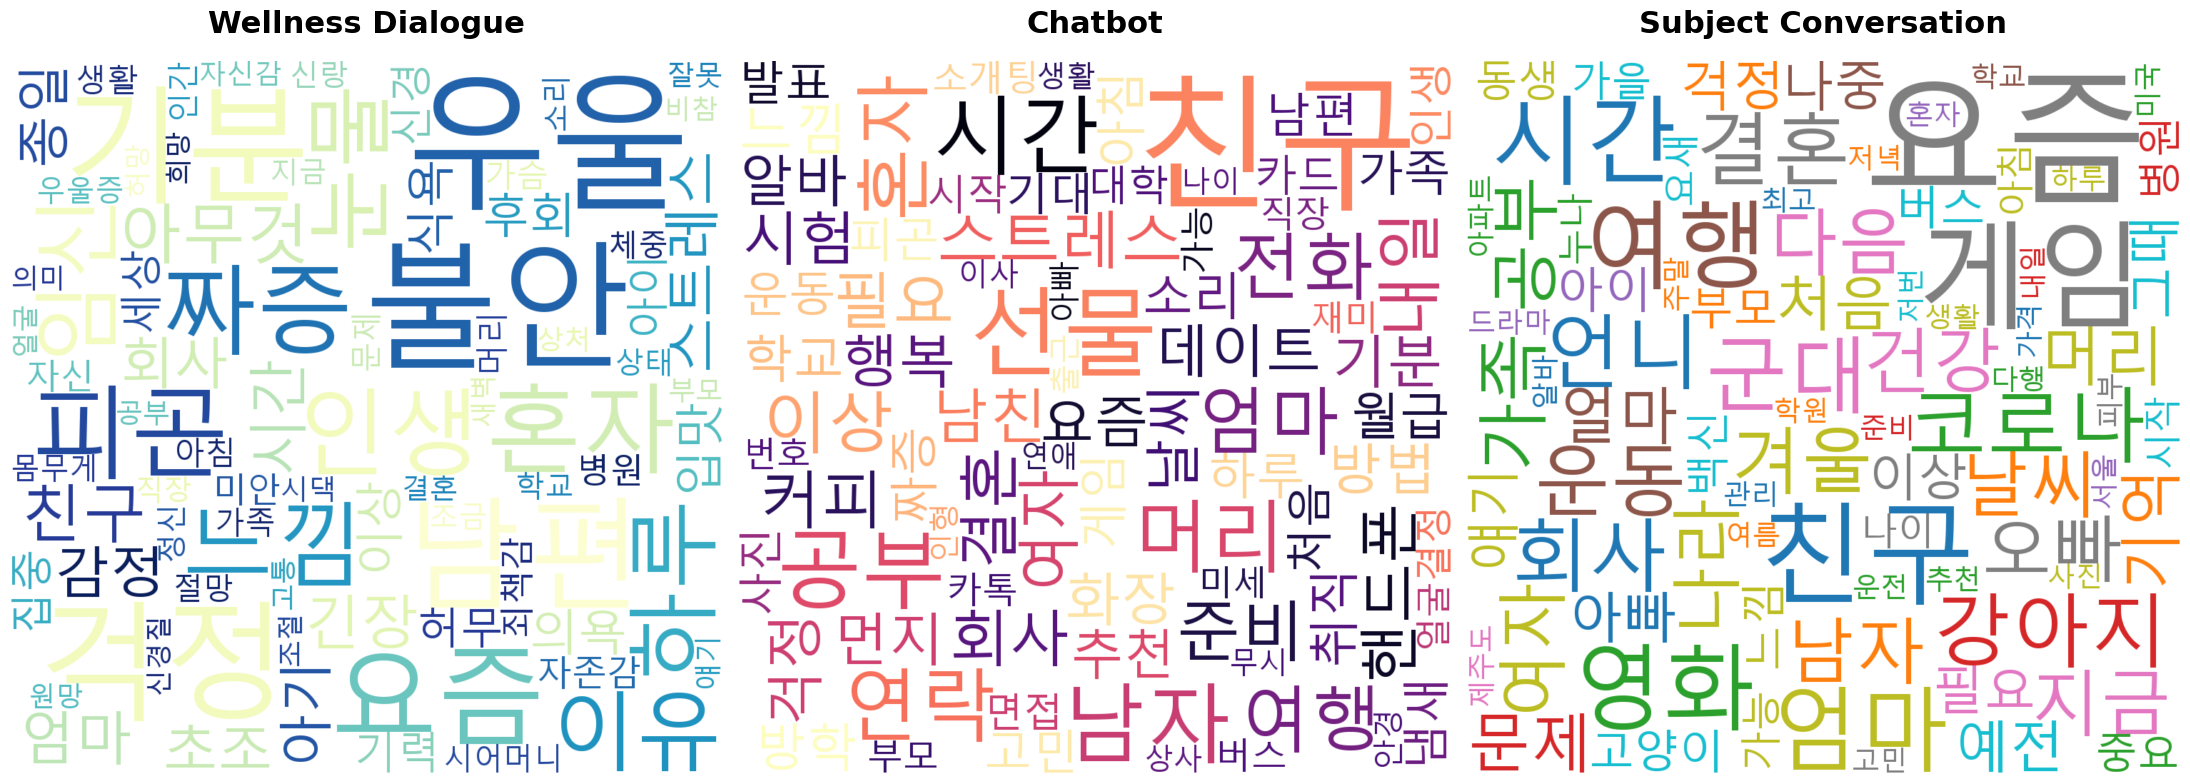

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from kiwipiepy import Kiwi
from collections import Counter

# 1. Kiwi 및 데이터 로드 (기존과 동일)
kiwi = Kiwi()
df_wellness = pd.read_csv('cleaned_wellness.csv')
df_subject = pd.read_csv('cleaned_subject.csv')
df_chatbot = pd.read_csv('cleaned_chatbot.csv')

# 2. 명사 추출 함수 (기존 로직 유지)
def get_pure_nouns_fixed(df, column_name='utterance'):
    sentences = df[column_name].astype(str).tolist()
    nouns = []
    for sent in sentences:
        if not sent.strip(): continue
        analysis = kiwi.analyze(sent)
        for token in analysis[0][0]:
            if token.tag in ['NNG', 'NNP'] and len(token.form) > 1:
                nouns.append(token.form)
    
    # 가독성을 저해하는 일반적인 단어들을 추가로 필터링
    stopwords = ['생각', '오늘', '하나', '무엇', '때문', '정도', '그거', '이번', '사람', '마음', '대해', '어디', '어떻게', '키키']
    filtered_nouns = [n for n in nouns if n not in stopwords]
    return Counter(filtered_nouns)

# 3. 시각화 설정
fig, axes = plt.subplots(1, 3, figsize=(22, 10)) # 가로 크기를 조금 더 키움

datasets = [df_wellness, df_chatbot, df_subject]
titles = ['Wellness Dialogue', 'Chatbot', 'Subject Conversation']

# [수정 포인트] 각 데이터셋에 어울리는 컬러맵 설정
cmaps = ['YlGnBu', 'magma', 'tab10'] 

print("세련된 색조합으로 워드클라우드 생성 중...")

for i, df in enumerate(datasets):
    counts = get_pure_nouns_fixed(df)
    
    if not counts:
        continue

    # [수정 포인트] 가독성을 극대화하는 옵션들 추가
    wc = WordCloud(
        font_path="malgun.ttf", 
        background_color="white", # 깔끔한 흰색 배경
        width=1000, height=1000,   # 해상도 높임
        max_words=80,             # 너무 많으면 지저분하므로 핵심 80개만
        colormap=cmaps[i],        # 테마별 색상 적용
        prefer_horizontal=0.8,    # 글자를 최대한 가로로 배치 (가독성 UP)
        max_font_size=200,         # 가장 큰 글자 크기 제한
        min_font_size=10,
        random_state=42           # 매번 돌릴 때마다 배치가 변하지 않게 고정
    ).generate_from_frequencies(counts)
    
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(titles[i], fontsize=22, pad=20, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

필터링 없이 모든 명사를 포함하여 워드클라우드를 생성 중입니다...


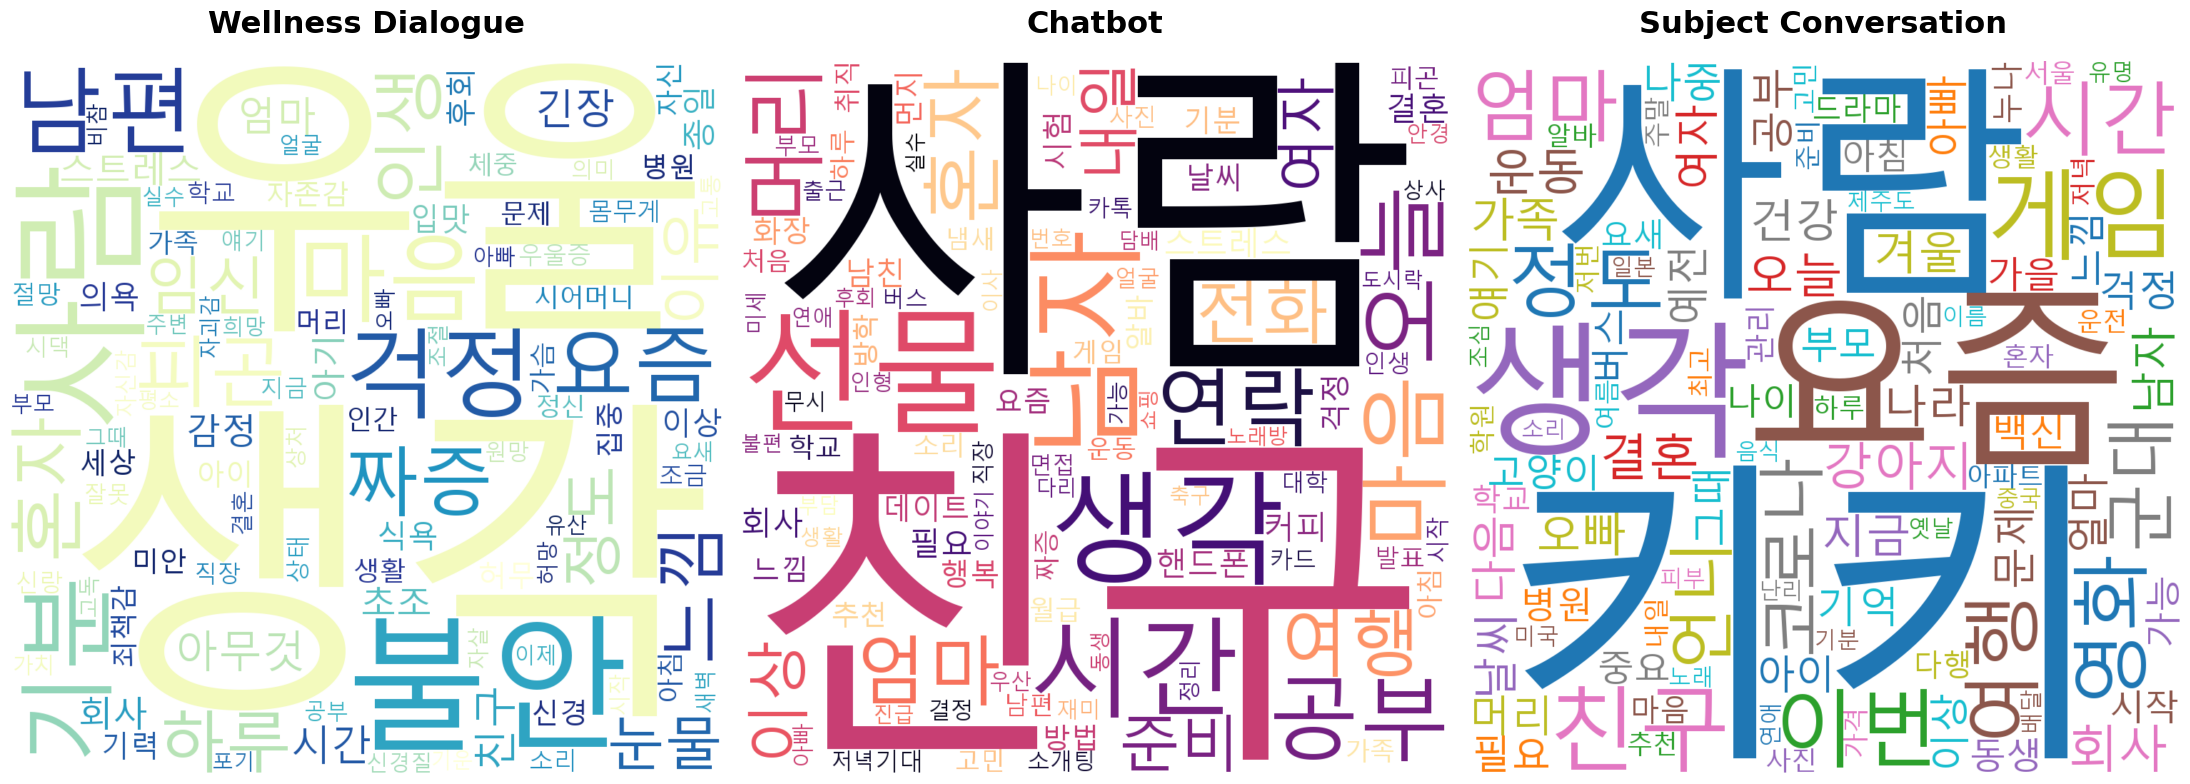

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from kiwipiepy import Kiwi
from collections import Counter

# 1. Kiwi 초기화 및 데이터 로드
kiwi = Kiwi()
df_wellness = pd.read_csv('cleaned_wellness.csv')
df_subject = pd.read_csv('cleaned_subject.csv')
df_chatbot = pd.read_csv('cleaned_chatbot.csv')

def get_nouns_no_filter(df, column_name='utterance'):
    # 데이터를 리스트로 변환
    sentences = df[column_name].astype(str).tolist()
    
    nouns = []
    # 문장별로 형태소 분석 수행
    for sent in sentences:
        if not sent.strip(): continue
        
        # Kiwi 분석 (문장 단위로 처리하여 속도 최적화)
        analysis = kiwi.analyze(sent)
        
        # 명사(NNG: 일반 명사, NNP: 고유 명사)만 추출
        # 불용어 리스트를 거치지 않고 2글자 이상이면 모두 수집합니다.
        for token in analysis[0][0]:
            if token.tag in ['NNG', 'NNP'] and len(token.form) > 1:
                nouns.append(token.form)
    
    return Counter(nouns)

# 2. 시각화 설정 (1행 3열)
fig, axes = plt.subplots(1, 3, figsize=(22, 10))

datasets = [df_wellness, df_chatbot, df_subject]
titles = ['Wellness Dialogue', 'Chatbot', 'Subject Conversation']

# [유지] 가독성이 검증된 세련된 컬러맵 조합
cmaps = ['YlGnBu', 'magma', 'tab10'] 

print("필터링 없이 모든 명사를 포함하여 워드클라우드를 생성 중입니다...")

for i, df in enumerate(datasets):
    # 모든 명사 빈도 계산
    counts = get_nouns_no_filter(df)
    
    if not counts:
        print(f"{titles[i]} 데이터에 명사가 없습니다.")
        continue

    # [유지] 가독성을 극대화하는 워드클라우드 설정
    wc = WordCloud(
        font_path="malgun.ttf", 
        background_color="white",
        width=1000, height=1000,
        max_words=100,             # 상위 100개 단어 표시
        colormap=cmaps[i],        # 요청하신 색조합 유지
        prefer_horizontal=0.8,     # 가독성을 위해 가로 글자 비중 높임 (0.8 = 80%)
        random_state=42            # 배치 고정
    ).generate_from_frequencies(counts)
    
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(titles[i], fontsize=22, pad=20, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

불용어 필터 없이 모든 명사를 포함한 워드클라우드를 생성 중입니다...


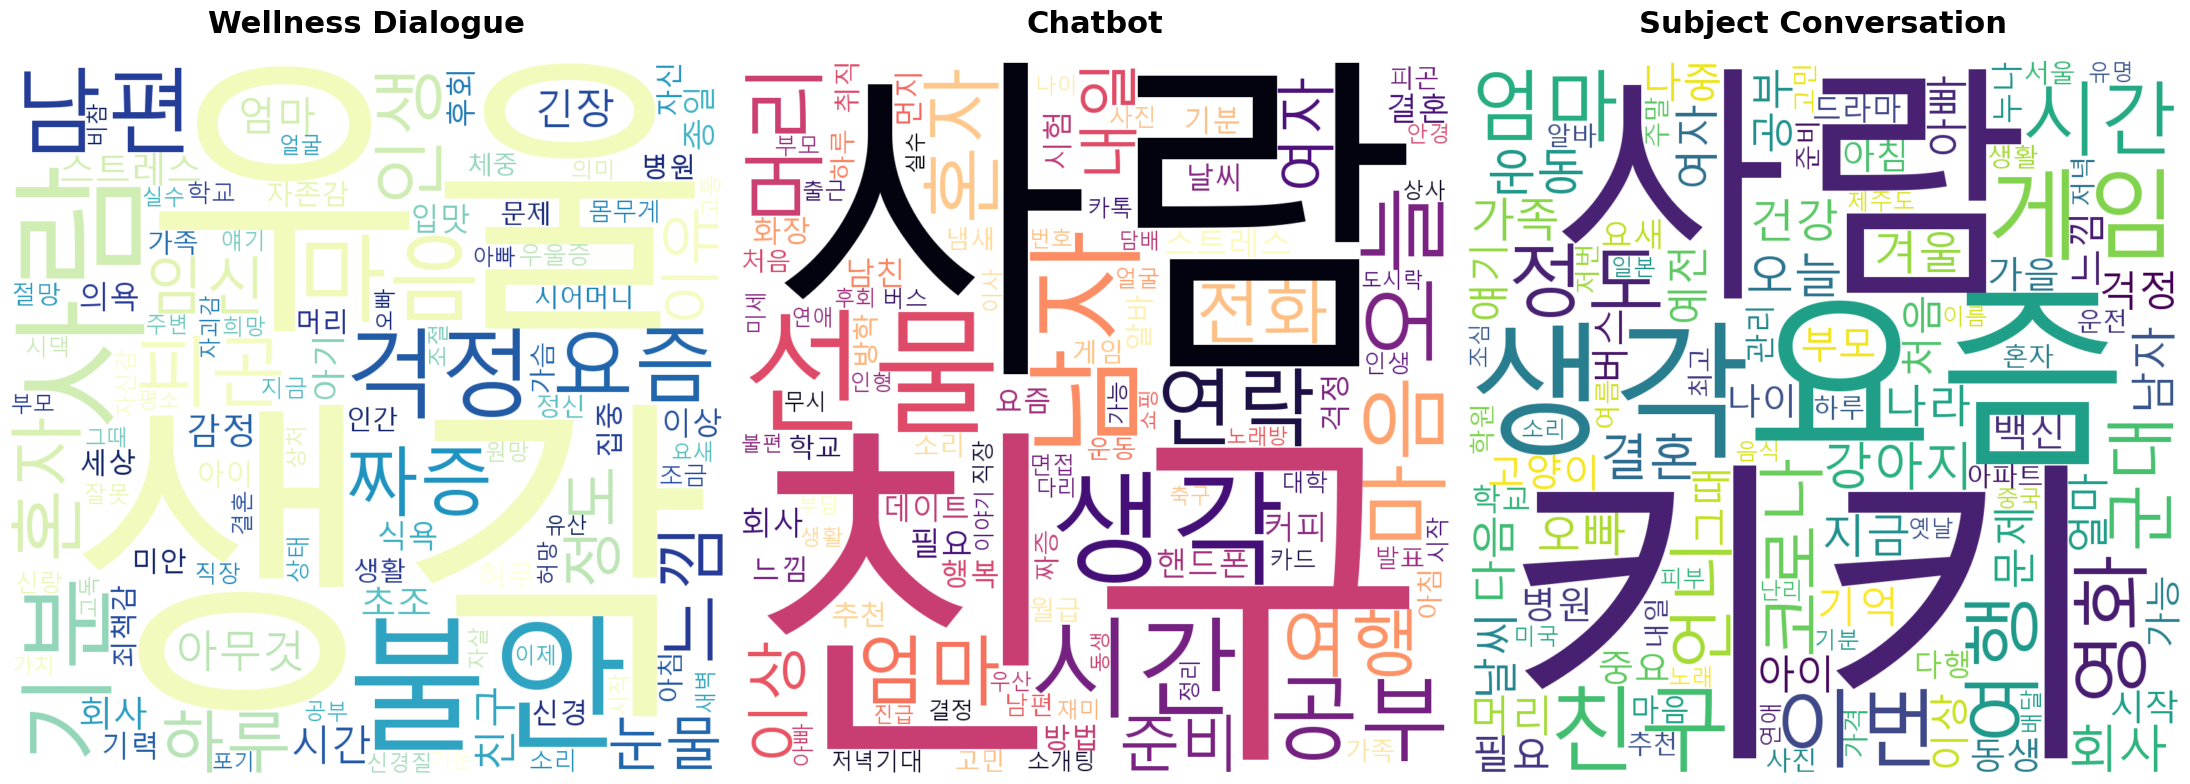

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from kiwipiepy import Kiwi
from collections import Counter

# 1. Kiwi 초기화 및 데이터 로드
kiwi = Kiwi()
df_wellness = pd.read_csv('cleaned_wellness.csv')
df_subject = pd.read_csv('cleaned_subject.csv')
df_chatbot = pd.read_csv('cleaned_chatbot.csv')

def get_all_nouns(df, column_name='utterance'):
    # 데이터를 리스트로 변환
    sentences = df[column_name].astype(str).tolist()
    
    nouns = []
    # 문장별로 형태소 분석 수행
    for sent in sentences:
        if not sent.strip(): continue
        
        analysis = kiwi.analyze(sent)
        # analysis[0][0]에서 명사(NNG, NNP)만 추출
        for token in analysis[0][0]:
            # 불용어 필터 없이 2글자 이상의 모든 명사를 수집
            if token.tag in ['NNG', 'NNP'] and len(token.form) > 1:
                nouns.append(token.form)
    
    return Counter(nouns)

# 2. 시각화 설정
fig, axes = plt.subplots(1, 3, figsize=(22, 10))

datasets = [df_wellness, df_chatbot, df_subject]
titles = ['Wellness Dialogue', 'Chatbot', 'Subject Conversation']
# 각 데이터셋의 개성을 살린 컬러맵
cmaps = ['YlGnBu', 'magma', 'viridis'] 

print("불용어 필터 없이 모든 명사를 포함한 워드클라우드를 생성 중입니다...")

for i, df in enumerate(datasets):
    # 명사 빈도 계산 (필터링 없음)
    counts = get_all_nouns(df)
    
    if not counts:
        print(f"{titles[i]} 데이터에 명사가 없습니다.")
        continue

    # 워드클라우드 생성 옵션
    wc = WordCloud(
        font_path="malgun.ttf", 
        background_color="white",
        width=1000, height=1000,
        max_words=100,             # 상위 100개 단어 표시
        colormap=cmaps[i],
        prefer_horizontal=0.8,     # 가독성을 위해 가로 글자 비중 높임
        random_state=42
    ).generate_from_frequencies(counts)
    
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(titles[i], fontsize=22, pad=20, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()